In [ ]:
pip install numpy pandas matplotlib scipy mne

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import mne

print("MNE version:", mne.__version__)
print("Everything is working!")

MNE version: 1.12.1
Everything is working!


In [3]:

import scipy.io as sio

data = sio.loadmat(
    "../data/gNautilus_CheckerboardVEP.mat",
    squeeze_me=True
)

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'ch_names', 'class_names', 'class_vec', 'event_marker', 'fs', 'group_id', 'sample_marker', 'y', 'y_filtered'])


In [4]:

ch_names = data["ch_names"]
fs = int(data["fs"])
eeg_data = data["y"]
filtered_data = data["y_filtered"]
events = data["event_marker"]

print("Sampling frequency:", fs)
print("Number of channels:", len(ch_names))
print("EEG data shape:", eeg_data.shape)
print("Filtered data shape:", filtered_data.shape)
print("Number of events:", len(events))
print("Channels:", ch_names)

Sampling frequency: 500
Number of channels: 16
EEG data shape: (25001, 16)
Filtered data shape: (25001, 16)
Number of events: 50
Channels: ['FP1' 'FP2' 'F3' 'Fz' 'F4' 'T7' 'C3' 'Cz' 'C4' 'T8' 'P3' 'Pz' 'P4' 'PO7'
 'PO8' 'Oz']


In [5]:

# Make sure EEG data is in the format MNE expects:
# channels × samples

eeg_for_mne = eeg_data.T

info = mne.create_info(
    ch_names=list(ch_names),
    sfreq=fs,
    ch_types="eeg"
)

raw = mne.io.RawArray(
    eeg_for_mne,
    info
)

print(raw)

Creating RawArray with float64 data, n_channels=16, n_times=25001
    Range : 0 ... 25000 =      0.000 ...    50.000 secs
Ready.
<RawArray | 16 x 25001 (50.0 s), ~3.1 MiB, data loaded>


In [6]:

print(raw.info["ch_names"])
print("Sampling frequency:", raw.info["sfreq"])
print("Number of channels:", raw.info["nchan"])

['FP1', 'FP2', 'F3', 'Fz', 'F4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P3', 'Pz', 'P4', 'PO7', 'PO8', 'Oz']
Sampling frequency: 500.0
Number of channels: 16


Using matplotlib as 2D backend.


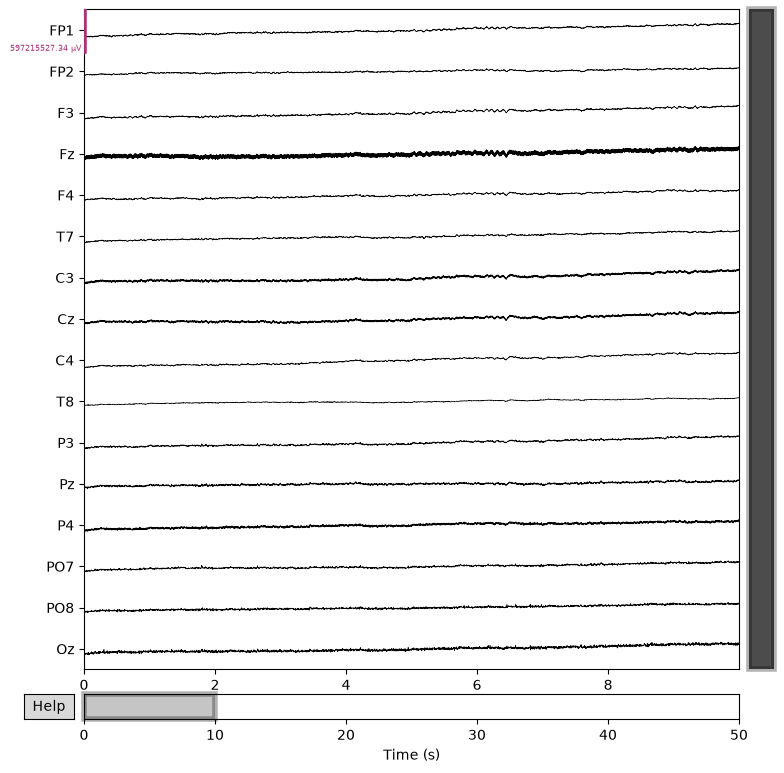

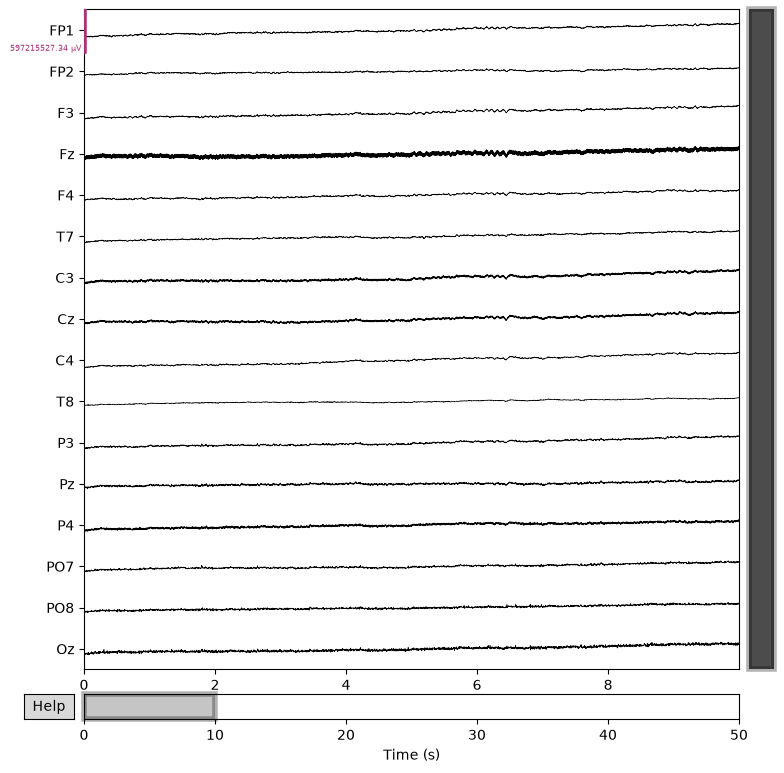

In [7]:
raw.plot(
    duration=10,
    n_channels=16,
    scalings="auto"
)

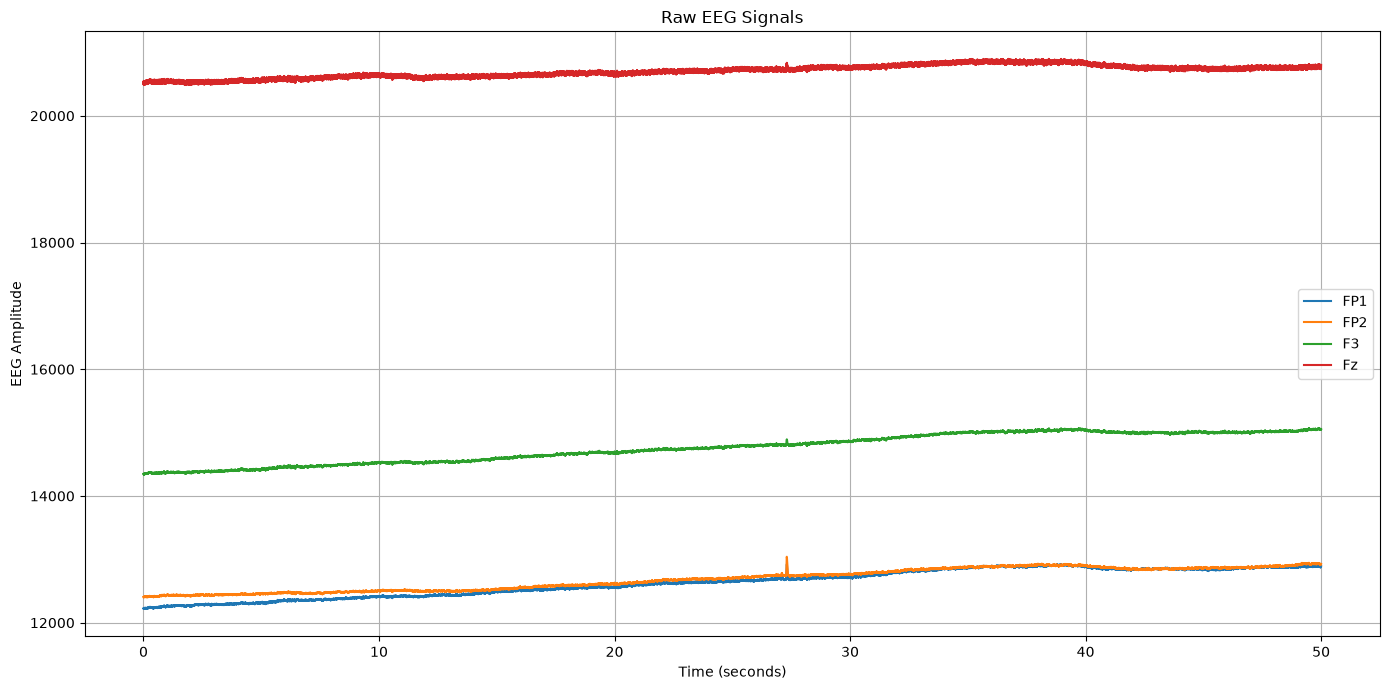

In [8]:
# Time axis
times = np.arange(eeg_data.shape[0]) / fs

# Plot 4 EEG channels
plt.figure(figsize=(14, 7))

for i in range(4):
    plt.plot(
        times,
        eeg_data[:, i],
        label=ch_names[i]
    )

plt.xlabel("Time (seconds)")
plt.ylabel("EEG Amplitude")
plt.title("Raw EEG Signals")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
print(ch_names)

['FP1' 'FP2' 'F3' 'Fz' 'F4' 'T7' 'C3' 'Cz' 'C4' 'T8' 'P3' 'Pz' 'P4' 'PO7'
 'PO8' 'Oz']


In [10]:
# Find the important visual channels
visual_channels = ["PO7", "PO8", "Oz"]

visual_indices = [
    list(ch_names).index(ch)
    for ch in visual_channels
]

print("Visual channel indices:", visual_indices)

Visual channel indices: [13, 14, 15]


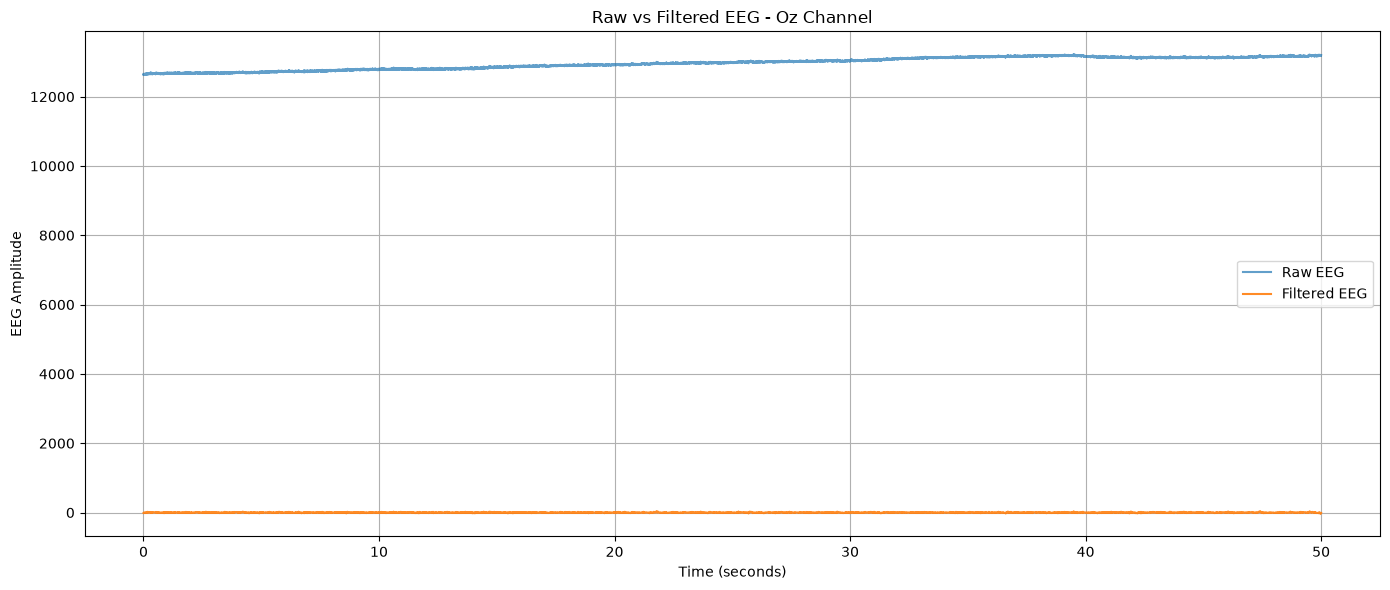

In [11]:
# Compare raw and filtered EEG at Oz

oz_index = list(ch_names).index("Oz")

plt.figure(figsize=(14, 6))

plt.plot(
    times,
    eeg_data[:, oz_index],
    label="Raw EEG",
    alpha=0.7
)

plt.plot(
    times,
    filtered_data[:, oz_index],
    label="Filtered EEG",
    alpha=0.9
)

plt.xlabel("Time (seconds)")
plt.ylabel("EEG Amplitude")
plt.title("Raw vs Filtered EEG - Oz Channel")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
print("Number of events:", len(events))
print("First 10 event markers:")
print(events[:10])


Number of events: 50
First 10 event markers:
[3170 3330 3746 4282 4570 5234 5898 6058 6346 6882]


In [13]:
mne_events = np.column_stack([
    events.astype(int),
    np.zeros(len(events), dtype=int),
    np.ones(len(events), dtype=int)
])

mne_events = mne_events.astype(int)

print("MNE events shape:", mne_events.shape)
print(mne_events[:10])

MNE events shape: (50, 3)
[[3170    0    1]
 [3330    0    1]
 [3746    0    1]
 [4282    0    1]
 [4570    0    1]
 [5234    0    1]
 [5898    0    1]
 [6058    0    1]
 [6346    0    1]
 [6882    0    1]]


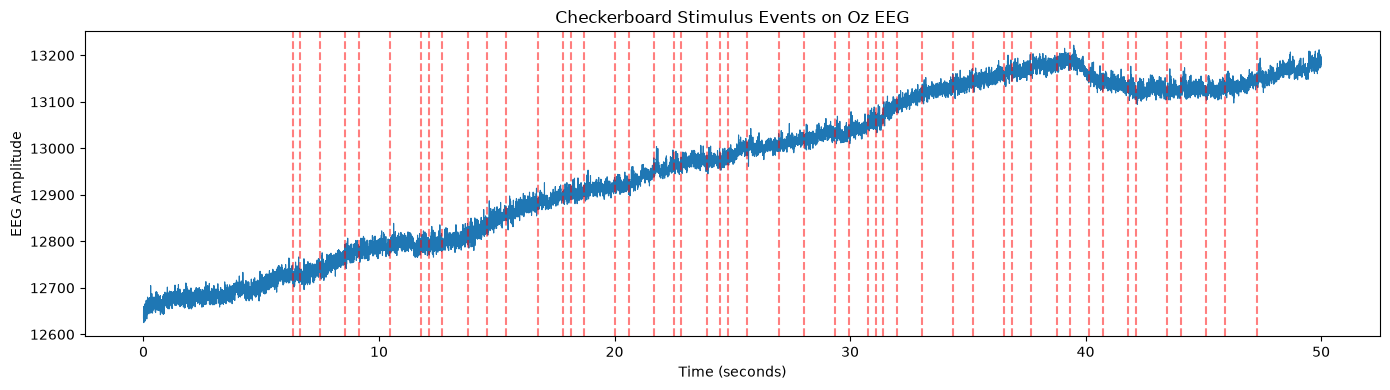

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    times,
    eeg_data[:, oz_index],
    linewidth=0.8
)

for event in events:
    event_time = event / fs
    ax.axvline(
        event_time,
        linestyle="--",
        alpha=0.5,
        color='red'
    )

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("EEG Amplitude")
ax.set_title("Checkerboard Stimulus Events on Oz EEG")

plt.tight_layout()
plt.show()

In [14]:
print("Event marker shape:", np.shape(events))
print("Event marker dtype:", events.dtype)
print("First 20 event markers:")
print(events[:20])

print("\nMinimum:", np.min(events))
print("Maximum:", np.max(events))
print("Unique values:", np.unique(events))

Event marker shape: (50,)
Event marker dtype: uint16
First 20 event markers:
[ 3170  3330  3746  4282  4570  5234  5898  6058  6346  6882  7297  7706
  8370  8906  9068  9355 10018 10306 10842 11258]

Minimum: 3170
Maximum: 23634
Unique values: [ 3170  3330  3746  4282  4570  5234  5898  6058  6346  6882  7297  7706
  8370  8906  9068  9355 10018 10306 10842 11258 11418 11956 12242 12410
 12818 13482 14018 14682 14970 15383 15546 15706 15994 16530 17194 17610
 18272 18434 18842 19384 19672 20082 20370 20906 21071 21730 22018 22556
 22970 23634]


In [15]:
# Convert event sample positions into MNE event format

mne_events = np.column_stack([
    events.astype(int),
    np.zeros(len(events), dtype=int),
    np.ones(len(events), dtype=int)
])

mne_events = mne_events.astype(int)

print("MNE events shape:", mne_events.shape)
print("First 10 MNE events:")
print(mne_events[:10])

MNE events shape: (50, 3)
First 10 MNE events:
[[3170    0    1]
 [3330    0    1]
 [3746    0    1]
 [4282    0    1]
 [4570    0    1]
 [5234    0    1]
 [5898    0    1]
 [6058    0    1]
 [6346    0    1]
 [6882    0    1]]


In [16]:
epochs = mne.Epochs(
    raw,
    mne_events,
    event_id={"checkerboard": 1},
    tmin=-0.2,
    tmax=0.8,
    baseline=(-0.2, 0),
    preload=True,
    reject_by_annotation=False
)

print(epochs)

Not setting metadata
50 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 50 events and 501 original time points ...
0 bad epochs dropped
<Epochs | 50 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~3.1 MiB, data loaded,
 'checkerboard': 50>


In [17]:
print("Number of epochs:", len(epochs))
print("Epoch start:", epochs.times[0], "seconds")
print("Epoch end:", epochs.times[-1], "seconds")
print("Number of channels:", len(epochs.ch_names))

Number of epochs: 50
Epoch start: -0.2 seconds
Epoch end: 0.8 seconds
Number of channels: 16


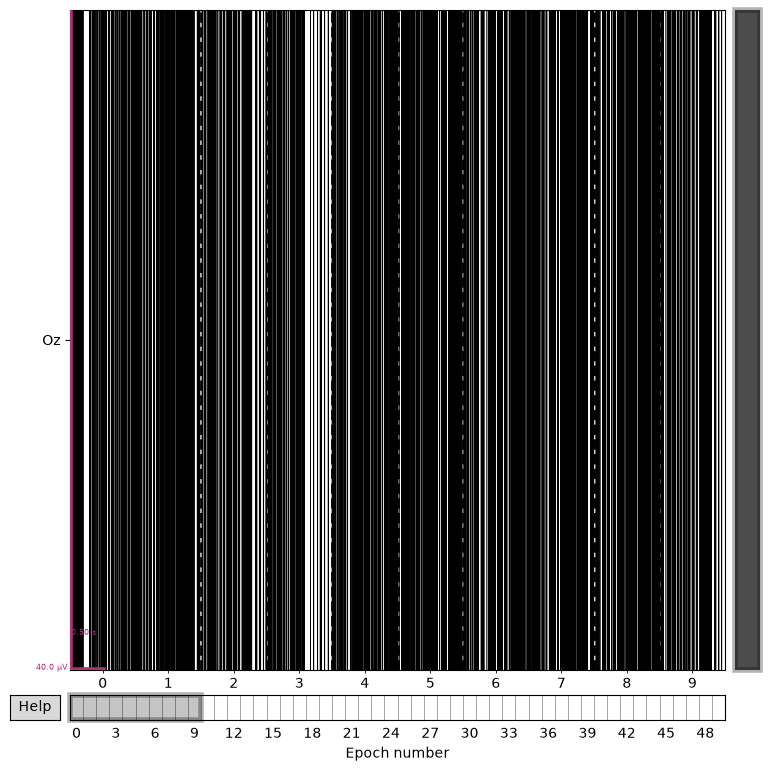

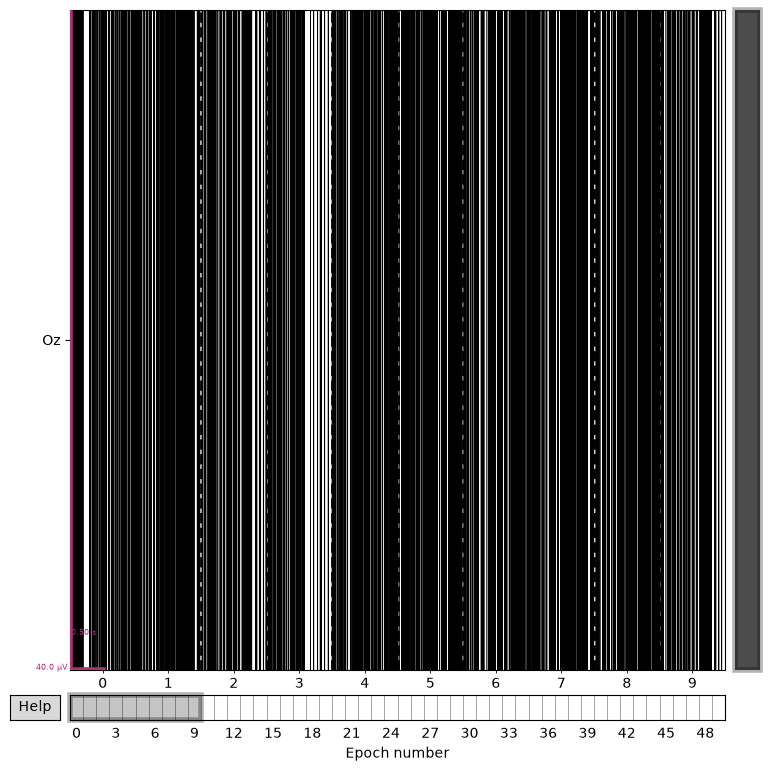

In [18]:
epochs["checkerboard"].plot(
    picks="Oz",
    n_epochs=10,
    n_channels=1
)

In [19]:
evoked = epochs["checkerboard"].average()

print(evoked)

<Evoked | 'checkerboard' (average, N=50), -0.2 – 0.8 s, baseline -0.2 – 0 s, 16 ch, ~79 KiB>


Need more than one channel to make topography for eeg. Disabling interactivity.


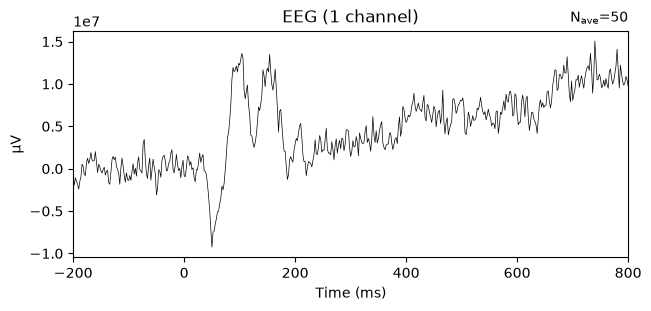

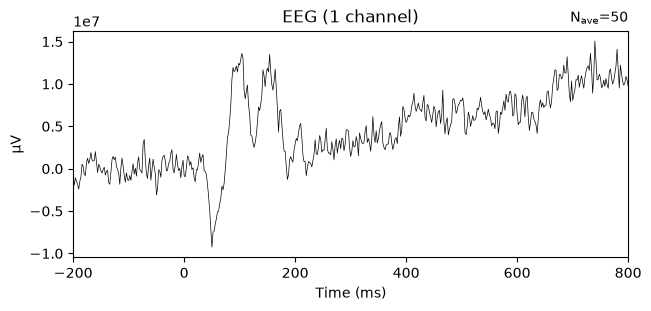

In [20]:
evoked.plot(
    picks="Oz",
    spatial_colors=False,
    time_unit="ms"
)

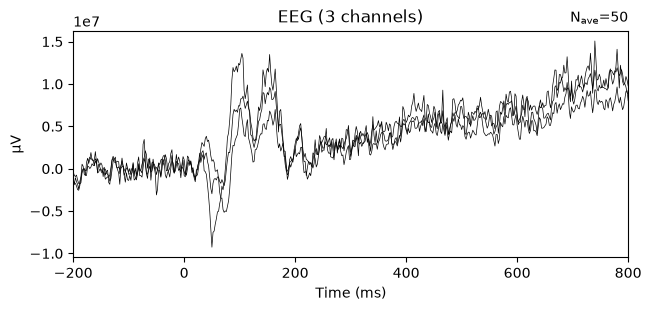

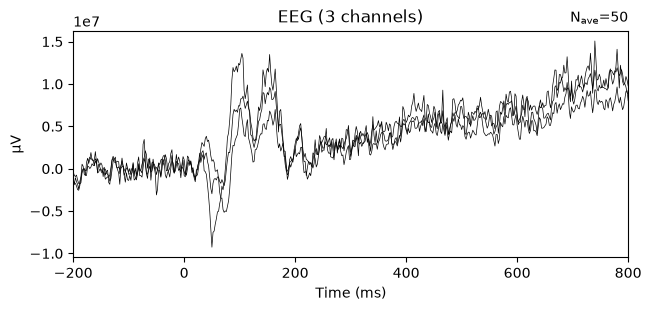

In [21]:
evoked.plot(
    picks=["PO7", "PO8", "Oz"],
    spatial_colors=False,
    time_unit="ms"
)